# MovieLens-1M Preprocessing Validation

This notebook validates the outputs generated by
`scripts/preprocess_movielens.py`.

Objectives

- Load the processed datasets
- Verify dataset dimensions
- Check for missing values
- Check for duplicate interactions
- Verify train/validation/test split integrity
- Verify temporal ordering
- Compute final dataset statistics

This notebook does **not** modify any data. It serves as a validation step before model training.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [21]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "movielens"
)

In [22]:
train = pd.read_csv(DATA_PATH / "train.csv")

validation = pd.read_csv(DATA_PATH / "validation.csv")

test = pd.read_csv(DATA_PATH / "test.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [23]:
summary = pd.DataFrame({

    "Dataset": [
        "Train",
        "Validation",
        "Test"
    ],

    "Interactions": [
        len(train),
        len(validation),
        len(test)
    ],

    "Users": [
        train.user_id.nunique(),
        validation.user_id.nunique(),
        test.user_id.nunique()
    ],

    "Movies": [
        train.movie_id.nunique(),
        validation.movie_id.nunique(),
        test.movie_id.nunique()
    ]

})

display(summary)

,Dataset,Interactions,Users,Movies
0,Train,562308,6034,3125
1,Validation,6034,6034,1768
2,Test,6034,6034,1798


In [24]:
print("Train")

display(train.isnull().sum())

print()

print("Validation")

display(validation.isnull().sum())

print()

print("Test")

display(test.isnull().sum())

Train


user_id      0
movie_id     0
timestamp    0
dtype: int64


Validation


user_id      0
movie_id     0
timestamp    0
dtype: int64


Test


user_id      0
movie_id     0
timestamp    0
dtype: int64

In [25]:
print("Train duplicates:", train.duplicated().sum())

print("Validation duplicates:", validation.duplicated().sum())

print("Test duplicates:", test.duplicated().sum())

Train duplicates: 0
Validation duplicates: 0
Test duplicates: 0


In [26]:
validation_counts = validation.groupby("user_id").size()

print(validation_counts.describe())

count    6034.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64


In [27]:
assert (validation_counts == 1).all()

print("Validation split is correct.")

Validation split is correct.


In [28]:
test_counts = test.groupby("user_id").size()

print(test_counts.describe())

count    6034.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64


In [29]:
assert (test_counts == 1).all()

print("Test split is correct.")

Test split is correct.


In [30]:
train_users = set(train.user_id.unique())

validation_users = set(validation.user_id.unique())

test_users = set(test.user_id.unique())

assert train_users == validation_users == test_users

print("All users appear in every split.")

All users appear in every split.


In [31]:
train_keys = set(zip(train.user_id, train.movie_id))

validation_keys = set(zip(validation.user_id, validation.movie_id))

test_keys = set(zip(test.user_id, test.movie_id))

assert train_keys.isdisjoint(validation_keys)

assert train_keys.isdisjoint(test_keys)

assert validation_keys.isdisjoint(test_keys)

print("No overlap detected.")

No overlap detected.


In [32]:
all_data = pd.concat([
    train.assign(split="train"),
    validation.assign(split="validation"),
    test.assign(split="test")
])

In [33]:
for user, df in all_data.groupby("user_id"):

    df = df.sort_values("timestamp")

    splits = list(df["split"])

    assert splits[-2] == "validation"

    assert splits[-1] == "test"

print("Temporal ordering verified.")

Temporal ordering verified.


In [34]:
num_users = train.user_id.nunique()

num_items = pd.concat([
    train,
    validation,
    test
]).movie_id.nunique()

num_interactions = (
    len(train)
    + len(validation)
    + len(test)
)

density = (
    num_interactions
    / (num_users * num_items)
)

sparsity = 1 - density

summary = pd.DataFrame({

    "Statistic": [

        "Users",
        "Movies",
        "Interactions",
        "Density",
        "Sparsity"

    ],

    "Value": [

        num_users,
        num_items,
        num_interactions,
        density,
        sparsity

    ]

})

display(summary)

,Statistic,Value
0,Users,6034.000000
1,Movies,3125.000000
2,Interactions,574376.000000
3,Density,0.030461
4,Sparsity,0.969539


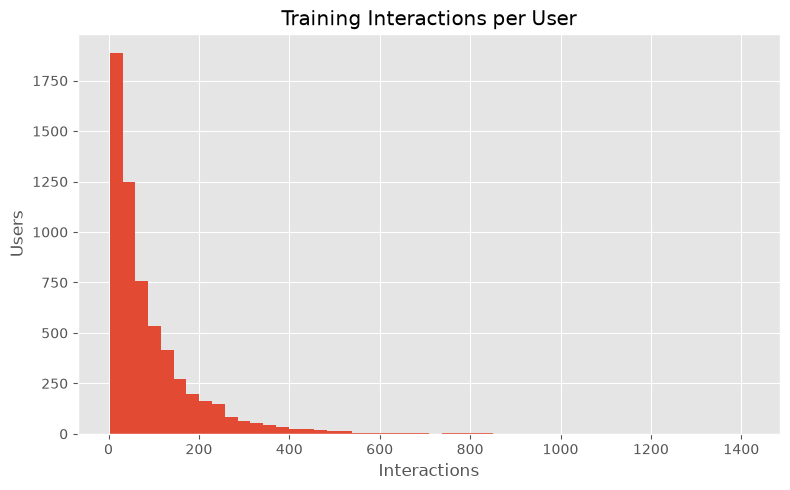

In [35]:
user_counts = train.groupby("user_id").size()

plt.figure(figsize=(8,5))

plt.hist(user_counts, bins=50)

plt.title("Training Interactions per User")

plt.xlabel("Interactions")

plt.ylabel("Users")

plt.tight_layout()

plt.show()

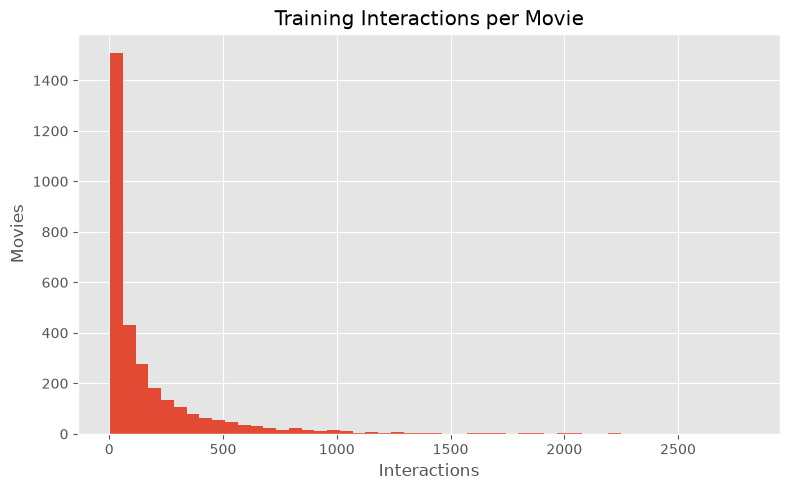

In [36]:
movie_counts = train.groupby("movie_id").size()

plt.figure(figsize=(8,5))

plt.hist(movie_counts, bins=50)

plt.title("Training Interactions per Movie")

plt.xlabel("Interactions")

plt.ylabel("Movies")

plt.tight_layout()

plt.show()

In [37]:
print("=" * 60)
print("PREPROCESSING VALIDATION COMPLETE")
print("=" * 60)

print()

print("All preprocessing checks passed successfully.")

print("Datasets are ready for RecBole.")

PREPROCESSING VALIDATION COMPLETE

All preprocessing checks passed successfully.
Datasets are ready for RecBole.


In [38]:
summary.to_csv(
    PROJECT_ROOT
    / "results"
    / "dataset_statistics.csv",
    index=False
)

## Conclusion

All preprocessing validation checks passed successfully.

The processed MovieLens-1M dataset satisfies:

- implicit feedback conversion
- iterative 5-core filtering
- chronological ordering
- leave-one-out splitting

The dataset is therefore suitable for RecBole model training and evaluation.